# Predict 30-day readmission

This ML project predicts the re-admission of a sample of patients whithin 30-days.

We use the available UCI Diabetes Readmission Dataset encoded from Kaggle

In [1]:
#import the necessary modules 
import numpy as np
import pandas as pd
#import sklearn as sk
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import sqlite3
import seaborn as sns
%matplotlib inline

In [2]:
#download the dataset from Kaggle

import kagglehub

# Download latest version
#path = kagglehub.dataset_download("chawthinn21/uci-diabetes-readmission-dataset-encoded")

#download the dirty dataset instead
path = kagglehub.dataset_download("brandao/diabetes")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\gemma\.cache\kagglehub\datasets\brandao\diabetes\versions\1


In [3]:
# Load dataset
from pathlib import Path
df = pd.read_csv(Path(path) / "diabetic_data.csv")
#df = pd.read_csv(Path(path) + "diabetes_cleaned_onehot.csv")  # adjust filename if needed

#let's clean the data with a mix of SQL and python to make it more efficient
#to understand what exactly to clean, lets check the columns names:
list(df.columns)
#print(df['medical_specialty'])

['encounter_id',
 'patient_nbr',
 'race',
 'gender',
 'age',
 'weight',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'payer_code',
 'medical_specialty',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'diag_1',
 'diag_2',
 'diag_3',
 'number_diagnoses',
 'max_glu_serum',
 'A1Cresult',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'change',
 'diabetesMed',
 'readmitted']

In [4]:
#drop the columns that are not interesting
df = df.drop(['payer_code','medical_specialty','max_glu_serum','A1Cresult', 'diag_1', 'diag_2', 'diag_3'], axis=1)

In [5]:
#change de columns with No to 0 and Yes 1 or Ch 1
df[df.select_dtypes(include="object").columns] = df.select_dtypes(include="object").map(
    lambda x: x.strip() if isinstance(x, str) else x
) #to include NO No\s, etc
df = df.replace({"No": 0, "Steady":0, "Up":1, "Down": -1, "Yes": 1, "Ch": 1})
#check the types of columns to see if we still have string values in the int tables
print(df.dtypes)

#find the mixed columns
mixed_cols = [
    col for col in df.select_dtypes(include="object").columns
    if pd.to_numeric(df[col], errors="coerce").notna().any()
    and pd.to_numeric(df[col], errors="coerce").isna().any()
]

C:\Users\gemma\AppData\Local\Temp\ipykernel_5068\2109154716.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df[df.select_dtypes(include="object").columns] = df.select_dtypes(include="object").map(
C:\Users\gemma\AppData\Local\Temp\ipykernel_5068\2109154716.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pa

encounter_id                 int64
patient_nbr                  int64
race                           str
gender                         str
age                            str
weight                         str
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
number_diagnoses             int64
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride                 object
acetohexamide               object
glipizide                   object
glyburide                   object
tolbutamide                 object
pioglitazone                object
rosiglitazone               object
acarbose            

C:\Users\gemma\AppData\Local\Temp\ipykernel_5068\2109154716.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  col for col in df.select_dtypes(include="object").columns


In [6]:
#check the problematic values

for cols in mixed_cols:
    print(cols)
    print(df[cols].unique()) #there should be none


In [7]:
# Create SQLite DB
conn = sqlite3.connect("hospital_clean.db")

# Write to SQL
df.to_sql("patients", conn, if_exists="replace", index=False)

#check columns
pd.read_sql("PRAGMA table_info(patients);", conn)

#preview data
pd.read_sql("SELECT * FROM patients LIMIT 5;", conn)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,0,0,0,0,0,0,0,0,0,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,0,1,0,0,0,0,0,1,1,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,0,0,0,0,0,0,0,0,1,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,0,1,0,0,0,0,0,1,1,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,0,0,0,0,0,0,0,1,1,NO


In [8]:
#clean with SQL
#first let's try to understand the columns we need to clean:
#Our model in this project does not understand string columns, basically we should add new columns with 0 (no) and 1 (yes)
#do this for the string columns that are: race, gender, age, weight and readmitted (the most important!!)
#check the values to clean:
str_cols = df.select_dtypes(include="str").columns
for col in str_cols:
    print(col)
    print(df[col].unique()) #there should be none

race
<StringArray>
['Caucasian', 'AfricanAmerican', '?', 'Other', 'Asian', 'Hispanic']
Length: 6, dtype: str
gender
<StringArray>
['Female', 'Male', 'Unknown/Invalid']
Length: 3, dtype: str
age
<StringArray>
[  '[0-10)',  '[10-20)',  '[20-30)',  '[30-40)',  '[40-50)',  '[50-60)',
  '[60-70)',  '[70-80)',  '[80-90)', '[90-100)']
Length: 10, dtype: str
weight
<StringArray>
[        '?',  '[75-100)',   '[50-75)',    '[0-25)', '[100-125)',   '[25-50)',
 '[125-150)', '[175-200)', '[150-175)',      '>200']
Length: 10, dtype: str
readmitted
<StringArray>
['NO', '>30', '<30']
Length: 3, dtype: str


In [9]:
#Clean with SQL
conn.execute("DROP TABLE IF EXISTS patients_clean;")

conn.execute("""
CREATE TABLE patients_clean AS                
SELECT
    patient_nbr,
    time_in_hospital,
    num_lab_procedures,
    num_medications,

    --race,
    CASE WHEN race = 'Caucasian' THEN 1 ELSE 0 END AS caucasian,
    CASE WHEN race = 'AfricanAmerican' THEN 1 ELSE 0 END AS african_american,
    CASE WHEN race = 'Asian' THEN 1 ELSE 0 END AS asian,
    CASE WHEN race = 'Hispanic' THEN 1 ELSE 0 END AS hispanic,
    CASE WHEN race = 'Other' THEN 1 ELSE 0 END AS other,
    CASE WHEN race = '?' THEN 1 ELSE 0 END AS unknown_race,

    --gender,
    CASE WHEN gender = 'Female' THEN 1 ELSE 0 END AS female,
    CASE WHEN gender = 'Male' THEN 1 ELSE 0 END AS male,
    CASE WHEN gender = 'Unknown/Invalid' THEN 1 ELSE 0 END AS unknown_gender,

    CASE WHEN age = '[0-10)' THEN 1 ELSE 0 END AS age_0_10,
    CASE WHEN age = '[10-20)' THEN 1 ELSE 0 END AS age_10_20,
    CASE WHEN age = '[20-30)' THEN 1 ELSE 0 END AS age_20_30,
    CASE WHEN age = '[30-40)' THEN 1 ELSE 0 END AS age_30_40,
    CASE WHEN age = '[40-50)' THEN 1 ELSE 0 END AS age_40_50,
    CASE WHEN age = '[50-60)' THEN 1 ELSE 0 END AS age_50_60,
    CASE WHEN age = '[60-70)' THEN 1 ELSE 0 END AS age_60_70,
    CASE WHEN age = '[70-80)' THEN 1 ELSE 0 END AS age_70_80,
    CASE WHEN age = '[80-90)' THEN 1 ELSE 0 END AS age_80_90,
    CASE WHEN age = '[90-100)' THEN 1 ELSE 0 END AS age_90_100,

    --weight,
    CASE WHEN weight = '?' THEN 1 ELSE 0 END AS unknown_weight,
    CASE WHEN weight = '[0-25)' THEN 1 ELSE 0 END AS w_0_25,
    CASE WHEN weight = '[25-50)' THEN 1 ELSE 0 END AS w_25_50,
    CASE WHEN weight = '[50-75)' THEN 1 ELSE 0 END AS w_50_75,
    CASE WHEN weight = '[75-100)' THEN 1 ELSE 0 END AS w_75_100,
    CASE WHEN weight = '[100-125)' THEN 1 ELSE 0 END AS w_100_125,
    CASE WHEN weight = '[125-150)' THEN 1 ELSE 0 END AS w_125_150,
    CASE WHEN weight = '[150-175)' THEN 1 ELSE 0 END AS w_150_175,
    CASE WHEN weight = '[175-200)' THEN 1 ELSE 0 END AS w_175_200,
    CASE WHEN weight = '>200' THEN 1 ELSE 0 END AS w_over_200,

    (number_inpatient + number_emergency + number_outpatient) AS total_visits,
             
    CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END AS readmitted

FROM patients
-- WHERE gender != 'Unknown/Invalid';
""")

conn.commit()

In [ ]:
#Load for ML
df_clean = pd.read_sql("SELECT * FROM patients_clean;", conn)
df_clean

,patient_nbr,time_in_hospital,num_lab_procedures,num_medications,caucasian,african_american,asian,hispanic,other,unknown_race,...,w_25_50,w_50_75,w_75_100,w_100_125,w_125_150,w_150_175,w_175_200,w_over_200,total_visits,readmitted
0,8222157,1,41,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,55629189,3,59,18,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,86047875,2,11,13,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,3,0
3,82442376,2,44,16,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,42519267,1,51,8,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,100162476,3,51,16,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
101762,74694222,5,33,18,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
101763,41088789,1,53,9,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
101764,31693671,10,45,21,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [11]:
#Understand the columns and information we have:
print(df_clean.shape)
print(df_clean.dtypes.value_counts()) #the data is already cleaned so they are all integers
df_clean.head(2)
print(df_clean['readmitted'].value_counts()) #0,1


(101766, 35)
int64    35
Name: count, dtype: int64
readmitted
0    90409
1    11357
Name: count, dtype: int64


In [ ]:
#when deciding which columns to drop, check for near-zero variance columns (not much info)

selector = VarianceThreshold(threshold=0.01)
selector.fit(df_clean.drop(columns=['readmitted'])) #temporarilly drop this column (the important result to train with)

low_var_cols = df_clean.drop(columns=['readmitted']).columns[~selector.get_support()].tolist() #get_support from sk checks values on weights importance
print(f"Low variance columns to drop ({len(low_var_cols)}): {low_var_cols}")

#drop the columns with low variance
df_model = df_clean.drop(columns=low_var_cols)
print(f"Remaining columns: {df_model.shape[1]}") #new dataset with less columns

Low variance columns to drop (12): ['asian', 'unknown_gender', 'age_0_10', 'age_10_20', 'w_0_25', 'w_25_50', 'w_50_75', 'w_100_125', 'w_125_150', 'w_150_175', 'w_175_200', 'w_over_200']
Remaining columns: 23


In [ ]:
#drop columns highly correlated with each other
X_temp = df_model.drop(columns=['readmitted']) #again, temporarily drop this
corr_matrix = X_temp.corr().abs() #correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)) #get upper corr
high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.95)] #check high correlation 
print(f"High-correlation columns to drop ({len(high_corr_cols)}): {high_corr_cols}")

#Drop values highly correlated
df_model = df_model.drop(columns=high_corr_cols)
print(f"Final column count: {df_model.shape[1]}")

High-correlation columns to drop (1): ['male']
Final column count: 22


In [ ]:
#train/test split
X=df_model.drop(columns=['readmitted'])
y=df_model['readmitted']

# 80% train, 20% test 
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train positive rate: {y_train.mean():.3f}")
print(f"Test positive rate:  {y_test.mean():.3f}")

Train: (81412, 21), Test: (20354, 21)
Train positive rate: 0.112
Test positive rate:  0.112


In [ ]:
#train a model, using random forest

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight='balanced',   
        random_state=42,
        n_jobs=-1
    ))
])

pipe.fit(X_train, y_train)
print("Training complete.")

Training complete.


In [ ]:
#Evaluate on the held out test set
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
)

y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Not Readmitted', 'Readmitted']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

                precision    recall  f1-score   support

Not Readmitted       0.91      0.70      0.80     18083
    Readmitted       0.17      0.47      0.24      2271

      accuracy                           0.68     20354
     macro avg       0.54      0.59      0.52     20354
  weighted avg       0.83      0.68      0.73     20354

ROC-AUC: 0.6334


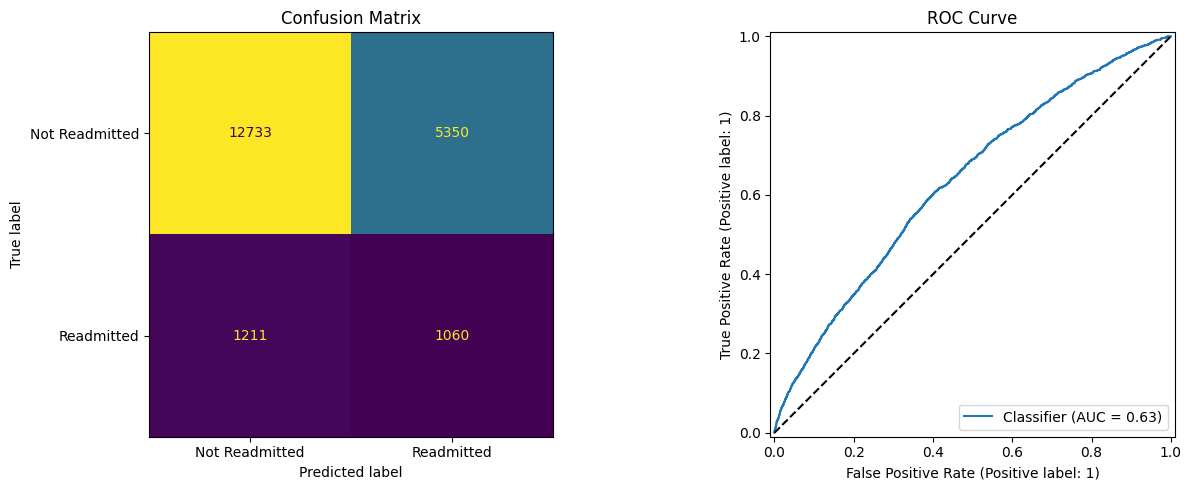

In [22]:
#Plot confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Not Readmitted', 'Readmitted'],
    ax=axes[0], colorbar=False
)
axes[0].set_title("Confusion Matrix")

#Plot ROC (Receiver Operating Characteristic curve) curve. 
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title("ROC Curve")
axes[1].plot([0,1],[0,1],'k--')

plt.tight_layout()
plt.show()

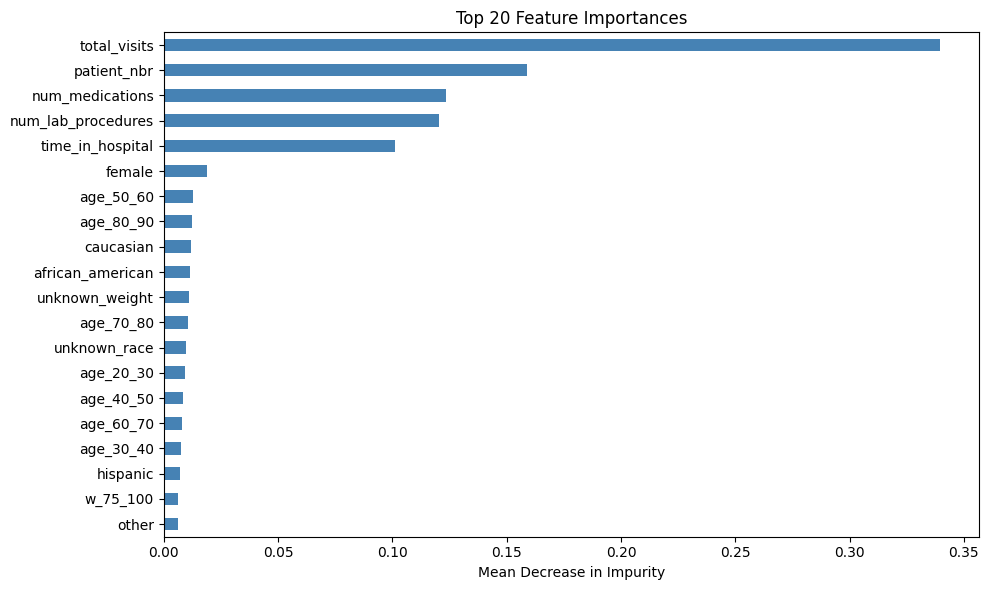

In [23]:
#Check the important features that decide if the patient is readmitted or not

rf_model = pipe.named_steps['clf'] #access the classifier step 
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns) #check importances
top20 = importances.sort_values(ascending=False).head(20) #find the top 20 parameters that matter

#plot
plt.figure(figsize=(10, 6))
top20.sort_values().plot(kind='barh', color='steelblue')
plt.title("Top 20 Feature Importances")
plt.xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()

In [24]:
#try another model, now logistic regression.

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

pipe_lr.fit(X_train, y_train)
y_proba_lr = pipe_lr.predict_proba(X_test)[:, 1]

print(f"Random Forest ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"Logistic Regression ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")

Random Forest ROC-AUC: 0.6334
Logistic Regression ROC-AUC: 0.6252
